<div dir="rtl" style="text-align:right">

# תרגול 15



1. כיצד LLM מייצר טקסט.
2. Function Calling, PDF, OCR, Cleaning, Chunking ו-Structured Output.
3. Embeddings, Bi-Encoder, Cross-Encoder ו-Re-ranking.

</div>

<div dir="rtl" style="text-align:right">

## הכנה

בהרצה הראשונה ייתכן שתידרש הורדה של שתי חבילות ושני מודלים קטנים מ-Hugging Face.  
אין צורך במפתח API.

</div>

In [6]:
import importlib.util
import subprocess
import sys

packages = {
    "fitz": "pymupdf>=1.23",
    "sentence_transformers": "sentence-transformers>=3.0",
    "sklearn": "scikit-learn>=1.3",
    "pydantic": "pydantic>=2.0"
}

for module_name, package_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package_name]
        )

print("All required packages are available.")

All required packages are available.


In [7]:
from pathlib import Path
import json
import math
import re

import fitz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML
from pydantic import BaseModel, Field
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer, CrossEncoder

np.random.seed(42)

PDF_FILENAME = "zvi_llm_retrieval_demo.pdf"

candidate_paths = [
    Path(PDF_FILENAME),
    Path("/content") / PDF_FILENAME,
    Path("/mnt/data") / PDF_FILENAME,
]

pdf_path = next(
    (path for path in candidate_paths if path.exists()),
    None
)

if pdf_path is None:
    try:
        from google.colab import files
        print(f"Please upload {PDF_FILENAME}")
        uploaded = files.upload()
        if PDF_FILENAME not in uploaded:
            raise FileNotFoundError(
                f"The uploaded file must be named {PDF_FILENAME}"
            )
        pdf_path = Path(PDF_FILENAME)
    except ImportError as exc:
        raise FileNotFoundError(
            f"Place {PDF_FILENAME} in the same folder as this notebook."
        ) from exc

print("Using PDF:", pdf_path.resolve())

Using PDF: C:\Users\royiz\VSCode_Projects\AI9\class15\zvi_llm_retrieval_demo.pdf


<div dir="rtl" style="text-align:right">

# 1. ה-PDF שבו נשתמש

**לפני ההרצה:**

1. למה עדיף בתרגול קצר להשתמש במסמך קטן ומובנה?
2. איזה Metadata נרצה לשמור מכל עמוד?
3. מדוע חשוב שהתשובה הסופית תכלול מספר עמוד?

</div>

Number of pages: 8
Metadata title: From LLMs to Retrieval - Teaching Demo


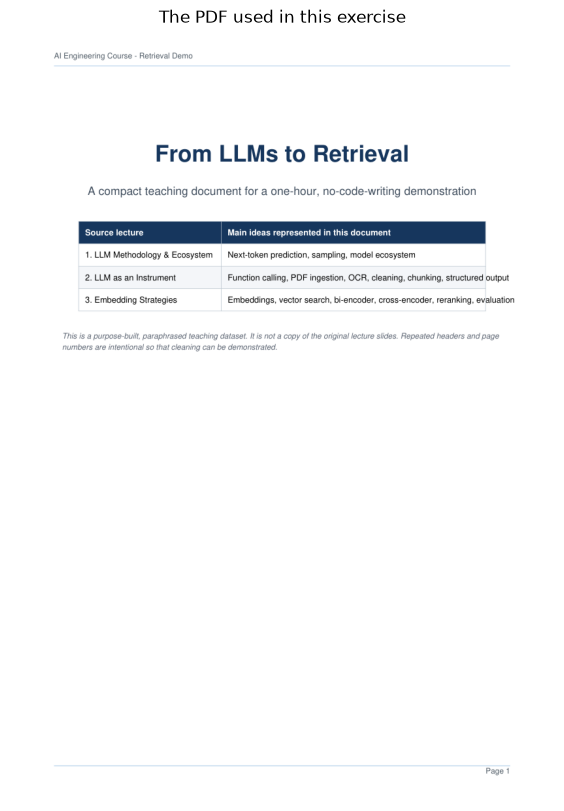

In [8]:
pdf_document = fitz.open(pdf_path)

print("Number of pages:", len(pdf_document))
print("Metadata title:", pdf_document.metadata.get("title"))

page = pdf_document[0]
pixmap = page.get_pixmap(
    matrix=fitz.Matrix(1.4, 1.4),
    alpha=False
)

image = np.frombuffer(
    pixmap.samples,
    dtype=np.uint8
).reshape(
    pixmap.height,
    pixmap.width,
    pixmap.n
)

plt.figure(figsize=(8, 10))
plt.imshow(image)
plt.axis("off")
plt.title("The PDF used in this exercise")
plt.show()

<div dir="rtl" style="text-align:right">

# 2. כיצד Temperature משנה את בחירת ה-Token הבא

המודל מחשב scores עבור tokens אפשריים. Temperature אינה מוסיפה ידע. היא משנה את חדות התפלגות הבחירה.

הקוד מתחיל מ-logits קבועים, מחלק אותם ב-Temperature ומפעיל Softmax.

```text
p_i = exp(z_i / T) / sum_j exp(z_j / T)
```

- כאשר `T < 1`, ההפרשים בין ה-logits מודגשים וההתפלגות חדה.
- כאשר `T > 1`, ההפרשים מצטמצמים וההתפלגות שטוחה יותר.


**נסו לחזות לפני ההרצה:**

1. באיזו Temperature token אחד ישלוט כמעט בכל ההסתברות?
2. באיזו Temperature נראה יותר גיוון?
3. איזו Temperature מתאימה יותר לשאלה עובדתית?

</div>

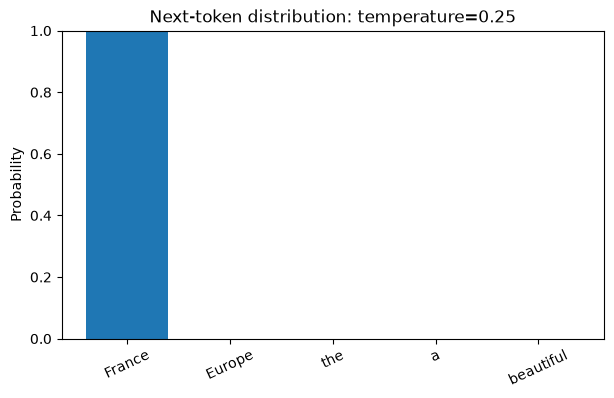

,token,probability
0,France,9.999859e-01
1,Europe,1.367400e-05
2,the,3.736247e-07
3,a,7.543352e-08
4,beautiful,1.020882e-08


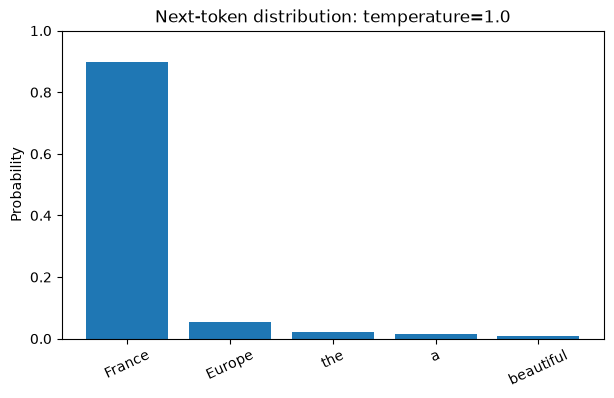

,token,probability
0,France,0.899153
1,Europe,0.054678
2,the,0.022230
3,a,0.014901
4,beautiful,0.009038


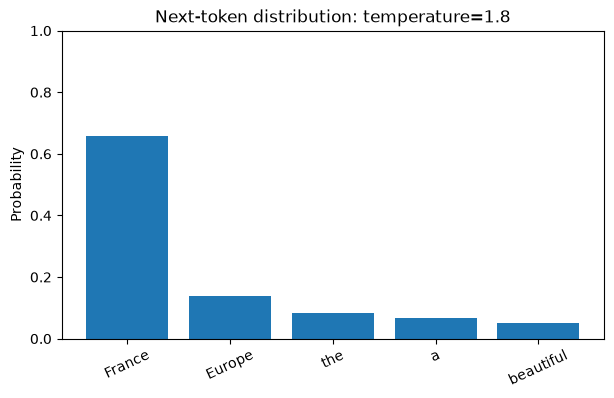

,token,probability
0,France,0.658218
1,Europe,0.138931
2,the,0.084266
3,a,0.067475
4,beautiful,0.051110


In [17]:
def softmax(values):
    values = np.asarray(values, dtype=float)
    shifted = values - values.max()
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()

candidate_tokens = [
    "France",
    "Europe",
    "the",
    "a",
    "beautiful"
]

base_logits = np.array([
    5.0,
    2.2,
    1.3,
    0.9,
    0.4
])

temperatures = [0.25, 1.0, 1.8]

for temperature in temperatures:
    probabilities = softmax(
        base_logits / temperature
    )

    plt.figure(figsize=(7, 4))
    plt.bar(candidate_tokens, probabilities)
    plt.ylim(0, 1)
    plt.ylabel("Probability")
    plt.title(
        "Next-token distribution: "
        f"temperature={temperature}"
    )
    plt.xticks(rotation=25)
    plt.show()

    display(
        pd.DataFrame({
            "token": candidate_tokens,
            "probability": probabilities
        }).sort_values(
            "probability",
            ascending=False
        )
    )

<div dir="rtl" style="text-align:right">

**שאלות לאחר ההרצה**

1. האם Temperature גבוהה הופכת את המודל לחכם יותר?
2. מה משתנה: הידע של המודל או דרך הדגימה?
3. מדוע אותו Prompt עשוי להחזיר ניסוחים שונים?

</div>

<div dir="rtl" style="text-align:right">

# 3. PDF Extraction ו-Cleaning

**לפני ההרצה:**

1. מה ההבדל בין PDF עם טקסט selectable לבין PDF סרוק?
2. מתי נדרש OCR?
3. האם כדאי למחוק את מספר העמוד או לשמור אותו כ-Metadata?
4. מה עלול לקרות אם נשאיר כותרת חוזרת בכל עמוד?

</div>

In [18]:
HEADER_TEXT = "AI Engineering Course - Retrieval Demo"

PAGE_TOPICS = {
    1: "Cover",
    2: "LLM generation",
    3: "Function calling",
    4: "PDF, cleaning, OCR",
    5: "Chunking",
    6: "Embeddings and vector stores",
    7: "Bi-encoder and reranking",
    8: "Retrieval evaluation"
}


def clean_page_text(raw_text):
    cleaned_lines = []

    for line in raw_text.splitlines():
        line = line.strip()

        if not line:
            continue

        if line == HEADER_TEXT:
            continue

        if re.fullmatch(r"Page\s+\d+", line):
            continue

        cleaned_lines.append(line)

    cleaned = " ".join(cleaned_lines)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    return cleaned


page_records = []

for page_index, page in enumerate(pdf_document):
    page_number = page_index + 1
    raw_text = page.get_text("text")

    page_records.append({
        "page": page_number,
        "topic": PAGE_TOPICS.get(
            page_number,
            f"Page {page_number}"
        ),
        "raw_text": raw_text,
        "clean_text": clean_page_text(raw_text)
    })

pages_df = pd.DataFrame(page_records)

display(
    pages_df[["page", "topic"]]
)

selected_page = pages_df.loc[
    pages_df["page"] == 4
].iloc[0]

comparison_df = pd.DataFrame({
    "version": ["Raw extraction", "After cleaning"],
    "text": [
        selected_page["raw_text"][:900],
        selected_page["clean_text"][:900]
    ]
})

display(comparison_df)

,page,topic
0,1,Cover
1,2,LLM generation
2,3,Function calling
3,4,"PDF, cleaning, OCR"
4,5,Chunking
5,6,Embeddings and vector stores
6,7,Bi-encoder and reranking
7,8,Retrieval evaluation


,version,text
0,Raw extraction,AI Engineering Course - Retrieval Demo\nPage 4...
1,After cleaning,"3. PDF Ingestion, Cleaning, and OCR Selectable..."


<div dir="rtl" style="text-align:right">

**שאלות לאחר ההרצה**

1. אילו פריטים הוסרו מהטקסט הנקי?
2. איזה מידע נשמר מחוץ לטקסט?
3. מה הסיכון ב-Cleaning אגרסיבי מדי?
4. למה OCR אינו ברירת המחדל לכל PDF?

</div>

<div dir="rtl" style="text-align:right">

# 4. Chunking

נשווה Fixed Chunking ללא חפיפה לאותה חלוקה עם 100 תווים של Overlap.

**לפני ההרצה:**

1. מה הבעיה ב-Chunk קטן מדי?
2. מה הבעיה ב-Chunk גדול מדי?
3. מה Overlap אמור לשמר?
4. מה המחיר של Overlap?

</div>

,strategy,number_of_chunks,average_length
0,"Fixed, no overlap",19,424.0
1,"Fixed, 100-char overlap",22,434.9


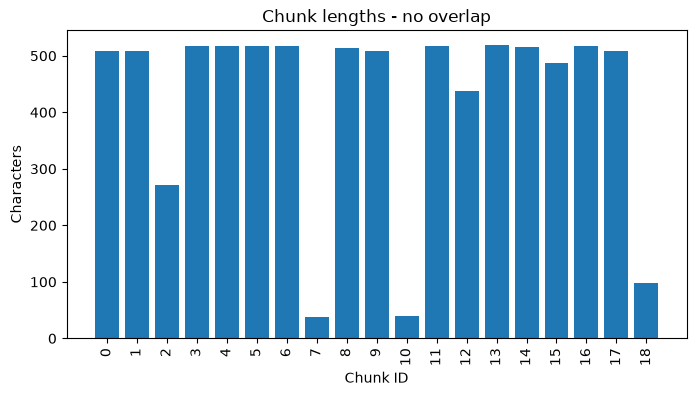

Page 4 - no overlap


Page 4 - with overlap


In [11]:
def chunk_pages(
    page_records,
    chunk_size=520,
    overlap=0
):
    chunks = []
    chunk_id = 0

    for record in page_records:
        if record["page"] == 1:
            continue

        text = record["clean_text"]
        start = 0

        while start < len(text):
            proposed_end = min(
                start + chunk_size,
                len(text)
            )

            end = proposed_end

            if proposed_end < len(text):
                last_space = text.rfind(
                    " ",
                    start + chunk_size // 2,
                    proposed_end
                )

                if last_space > start:
                    end = last_space

            chunk_text = text[start:end].strip()

            if chunk_text:
                chunks.append({
                    "chunk_id": chunk_id,
                    "page": record["page"],
                    "topic": record["topic"],
                    "start": start,
                    "end": end,
                    "text": chunk_text,
                    "length": len(chunk_text)
                })
                chunk_id += 1

            if end >= len(text):
                break

            start = max(
                end - overlap,
                start + 1
            )

    return pd.DataFrame(chunks)


chunks_no_overlap = chunk_pages(
    page_records,
    chunk_size=520,
    overlap=0
)

chunks_overlap = chunk_pages(
    page_records,
    chunk_size=520,
    overlap=100
)

summary = pd.DataFrame({
    "strategy": [
        "Fixed, no overlap",
        "Fixed, 100-char overlap"
    ],
    "number_of_chunks": [
        len(chunks_no_overlap),
        len(chunks_overlap)
    ],
    "average_length": [
        chunks_no_overlap["length"].mean(),
        chunks_overlap["length"].mean()
    ]
})

display(summary.round(1))

plt.figure(figsize=(8, 4))
plt.bar(
    chunks_no_overlap["chunk_id"].astype(str),
    chunks_no_overlap["length"]
)
plt.xlabel("Chunk ID")
plt.ylabel("Characters")
plt.title("Chunk lengths - no overlap")
plt.xticks(rotation=90)
plt.show()


def show_chunks(dataframe, page_number, maximum=5):
    subset = dataframe[
        dataframe["page"] == page_number
    ].head(maximum)

    colors_list = [
        "#EAF3F8",
        "#FFF2CC",
        "#E2F0D9",
        "#FCE4D6",
        "#E4DFEC"
    ]

    blocks = []

    for position, (_, row) in enumerate(
        subset.iterrows()
    ):
        background = colors_list[
            position % len(colors_list)
        ]

        blocks.append(
            f"""
            <div style='background:{background};
                        border:1px solid #9AA6B2;
                        border-radius:8px;
                        padding:10px;
                        margin:8px 0;'>
              <b>Chunk {row['chunk_id']}</b>
              - chars {row['start']}:{row['end']}<br>
              {row['text']}
            </div>
            """
        )

    display(HTML("".join(blocks)))


print("Page 4 - no overlap")
show_chunks(
    chunks_no_overlap,
    page_number=4
)

print("Page 4 - with overlap")
show_chunks(
    chunks_overlap,
    page_number=4
)

<div dir="rtl" style="text-align:right">

**שאלות לאחר ההרצה**

1. למה מספר ה-Chunks גדל כאשר מוסיפים Overlap?
2. האם Overlap מבטיח שה-Retrieval יהיה טוב יותר?
3. איזו אסטרטגיה צורכת יותר אחסון וחישוב Embeddings?
4. האם ניתן לבחור Chunking נכון בלי Benchmark של שאלות?

</div>

<div dir="rtl" style="text-align:right">

# 5. Embeddings

כל Chunk הופך לווקטור בגודל קבוע. נציג את מטריצת ה-Embeddings ונקרין אותה ל-2D באמצעות PCA.

**לפני ההרצה:**

1. מה מייצגת כל שורה במטריצת Embeddings?
2. האם לכל ממד יש בהכרח שם אנושי ברור?
3. האם נקודות קרובות ב-PCA בהכרח קרובות באותה מידה במרחב המקורי?

</div>

c:\Users\royiz\anaconda3\envs\course_env\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\royiz\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3236.88it/s]
'[WinError 10054] An

Number of chunks: 22
Embedding matrix shape: (22, 384)
First 10 values of the first embedding:
[-0.06874403 -0.05779749  0.02166041  0.07941378  0.02045107  0.04462965
  0.05497413  0.04180876  0.11487224  0.03544368]


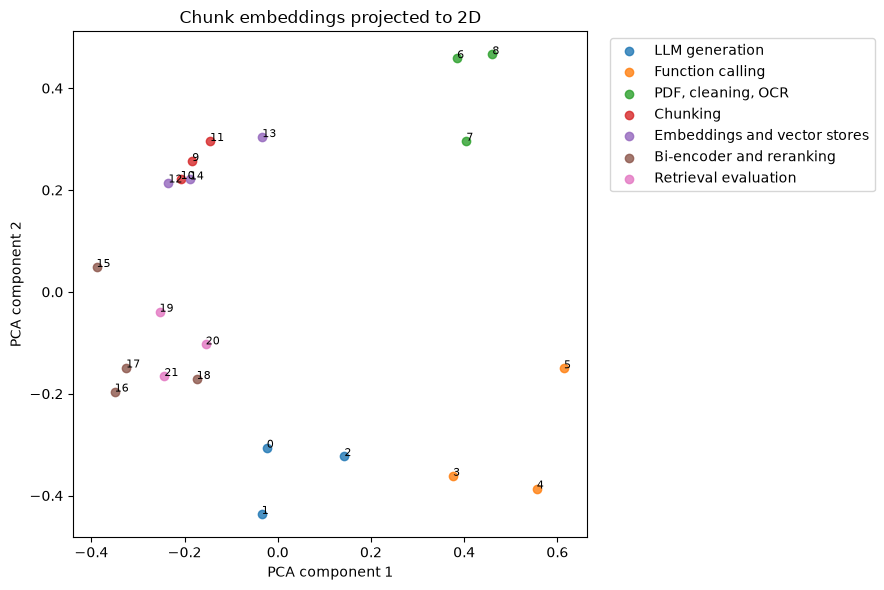

Explained variance ratio: [0.14838524 0.12085824]


In [12]:
BI_ENCODER_NAME = (
    "sentence-transformers/"
    "all-MiniLM-L6-v2"
)

bi_encoder = SentenceTransformer(
    BI_ENCODER_NAME
)

chunks = chunks_overlap.copy().reset_index(drop=True)

chunk_embeddings = bi_encoder.encode(
    chunks["text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=False
)

print("Number of chunks:", len(chunks))
print("Embedding matrix shape:", chunk_embeddings.shape)
print("First 10 values of the first embedding:")
print(chunk_embeddings[0, :10])

pca = PCA(
    n_components=2,
    random_state=42
)

points_2d = pca.fit_transform(
    chunk_embeddings
)

plt.figure(figsize=(9, 6))

for topic in chunks["topic"].unique():
    mask = chunks["topic"] == topic

    plt.scatter(
        points_2d[mask, 0],
        points_2d[mask, 1],
        label=topic,
        alpha=0.8
    )

for row_index, row in chunks.iterrows():
    plt.text(
        points_2d[row_index, 0],
        points_2d[row_index, 1],
        str(row["chunk_id"]),
        fontsize=8
    )

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Chunk embeddings projected to 2D")
plt.legend(
    bbox_to_anchor=(1.03, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

<div dir="rtl" style="text-align:right">

**שאלות לאחר ההרצה**

1. למה ה-Embedding Matrix היא `[number_of_chunks, 384]`?
2. האם מספר ממדים גדול יותר מבטיח Retrieval טוב יותר?
3. מדוע PCA היא המחשה בלבד?
4. האם Chunks מאותו עמוד חייבים להופיע באותה קבוצה?

</div>

<div dir="rtl" style="text-align:right">

# 6. Semantic Retrieval באמצעות Bi-Encoder

השאילתה אינה משתמשת במילה `OCR`, אך משמעותה דומה לקטע שעוסק בזיהוי טקסט מתוך תמונות.

**לפני ההרצה:**

1. האם Keyword Search היה בהכרח מוצא את הקטע הנכון?
2. למה אפשר לחשב מראש את Embeddings של ה-Chunks?
3. האם Cosine Similarity של 0.8 פירושה 80% הסתברות שהתוצאה נכונה?

</div>

Query: When must text be recognized from images inside a PDF?


,rank,page,topic,retrieval_score,preview
6,1,4,"PDF, cleaning, OCR",0.626,"3. PDF Ingestion, Cleaning, and OCR Selectable..."
8,2,4,"PDF, cleaning, OCR",0.580,system to display citations or open the origin...
12,3,6,Embeddings and vector stores,0.294,5. Embeddings and Vector Stores Embeddings An ...
13,4,6,Embeddings and vector stores,0.282,ng text from page images may retrieve a chunk ...
7,5,4,"PDF, cleaning, OCR",0.247,"s, broken line wraps, duplicated whitespace, a..."
9,6,5,Chunking,0.205,4. Chunking Strategies Why chunk documents Lon...


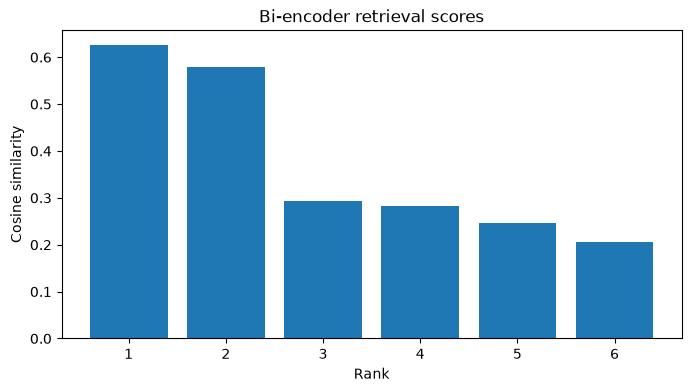

In [13]:
def bi_encoder_search(query, top_k=5):
    query_embedding = bi_encoder.encode(
        [query],
        normalize_embeddings=True,
        show_progress_bar=False
    )[0]

    scores = chunk_embeddings @ query_embedding
    ranking = np.argsort(scores)[::-1][:top_k]

    results = chunks.iloc[ranking].copy()
    results["retrieval_score"] = scores[ranking]
    results["rank"] = range(1, len(results) + 1)

    return results[
        [
            "rank",
            "chunk_id",
            "page",
            "topic",
            "retrieval_score",
            "text"
        ]
    ]


query = (
    "When must text be recognized "
    "from images inside a PDF?"
)

bi_results = bi_encoder_search(
    query,
    top_k=6
)

print("Query:", query)

display(
    bi_results.assign(
        preview=bi_results["text"].str.slice(0, 160)
    )[
        [
            "rank",
            "page",
            "topic",
            "retrieval_score",
            "preview"
        ]
    ].round({"retrieval_score": 3})
)

plt.figure(figsize=(8, 4))
plt.bar(
    bi_results["rank"].astype(str),
    bi_results["retrieval_score"]
)
plt.xlabel("Rank")
plt.ylabel("Cosine similarity")
plt.title("Bi-encoder retrieval scores")
plt.show()

<div dir="rtl" style="text-align:right">

**שאלות לאחר ההרצה**

1. מאיזה עמוד הגיע ה-Chunk הראשון?
2. האם כל תוצאה ב-Top-6 באמת עונה על השאלה?
3. כיצד הגדלת `top_k` משפיעה על Recall ועל Precision?
4. מה יקרה אם נשתמש במודל Embedding אחר לשאילתה מאשר למסמכים?

</div>

<div dir="rtl" style="text-align:right">

# 7. Cross-Encoder ו-Re-ranking

ה-Bi-Encoder מהיר משום שהוא מקודד את השאילתה והמסמכים בנפרד. ה-Cross-Encoder איטי יותר, אך מקבל את זוג הטקסטים יחד ויכול לזהות התאמות עדינות יותר.

**לפני ההרצה:**

1. איזה מודל מתאים לחיפוש ראשוני במיליון מסמכים?
2. למה אי אפשר לשמור מראש Cross-Encoder score לכל מסמך?
3. מה יקרה אם ה-Chunk הנכון לא נכנס ל-Top-k הראשוני?

</div>

c:\Users\royiz\anaconda3\envs\course_env\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\royiz\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5019.45it/s]


Query: When should reranking be avoided?


,chunk_id,page,bi_rank,cross_rank,retrieval_score,cross_score,preview
0,17,7,2,1,0.423,8.026,"t, when precision is important, or when first-..."
1,16,7,1,2,0.441,-0.402,r receives the query and a candidate chunk tog...
2,18,7,7,3,0.260,-1.399,"lready sufficiently precise, or when the task ..."
3,19,8,6,4,0.278,-7.025,7. Retrieval Evaluation and the Final Pipeline...
4,15,7,5,5,0.284,-8.134,"6. Bi-Encoder, Cross-Encoder, and Reranking Bi..."
5,21,8,4,6,0.298,-8.761,", embed the user query, retrieve top candidate..."
6,20,8,3,7,0.369,-9.655,irst k positions. Precision@k measures how man...
7,14,6,8,8,0.237,-11.411,be used for documents and queries. Similarity ...


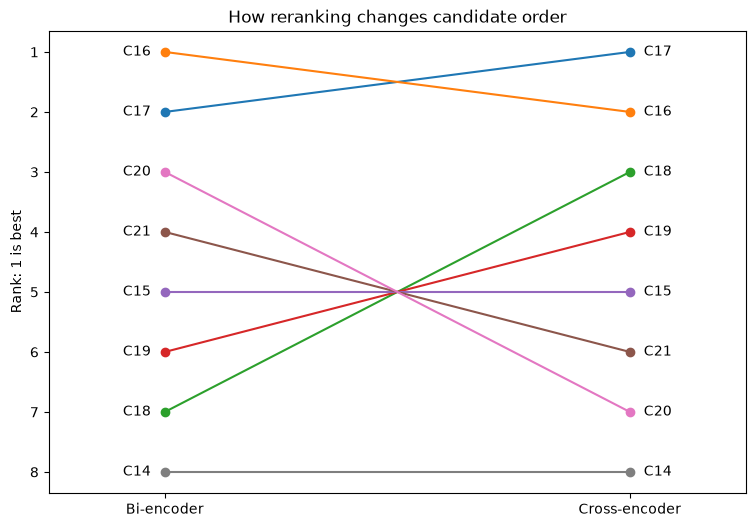

In [14]:
CROSS_ENCODER_NAME = (
    "cross-encoder/"
    "ms-marco-MiniLM-L-6-v2"
)

cross_encoder = CrossEncoder(
    CROSS_ENCODER_NAME
)

rerank_query = "When should reranking be avoided?"

candidate_results = bi_encoder_search(
    rerank_query,
    top_k=8
).copy()

pairs = [
    [rerank_query, text]
    for text in candidate_results["text"]
]

candidate_results["cross_score"] = (
    cross_encoder.predict(pairs)
)

candidate_results["bi_rank"] = (
    candidate_results["rank"]
)

reranked = candidate_results.sort_values(
    "cross_score",
    ascending=False
).reset_index(drop=True)

reranked["cross_rank"] = range(
    1,
    len(reranked) + 1
)

rank_comparison = reranked[
    [
        "chunk_id",
        "page",
        "topic",
        "bi_rank",
        "cross_rank",
        "retrieval_score",
        "cross_score",
        "text"
    ]
].copy()

rank_comparison["preview"] = (
    rank_comparison["text"].str.slice(0, 145)
)

print("Query:", rerank_query)

display(
    rank_comparison[
        [
            "chunk_id",
            "page",
            "bi_rank",
            "cross_rank",
            "retrieval_score",
            "cross_score",
            "preview"
        ]
    ].round({
        "retrieval_score": 3,
        "cross_score": 3
    })
)

plt.figure(figsize=(9, 6))

for _, row in rank_comparison.iterrows():
    plt.plot(
        [0, 1],
        [row["bi_rank"], row["cross_rank"]],
        marker="o"
    )

    plt.text(
        -0.03,
        row["bi_rank"],
        f"C{row['chunk_id']}",
        ha="right",
        va="center"
    )

    plt.text(
        1.03,
        row["cross_rank"],
        f"C{row['chunk_id']}",
        ha="left",
        va="center"
    )

plt.xticks(
    [0, 1],
    ["Bi-encoder", "Cross-encoder"]
)
plt.ylabel("Rank: 1 is best")
plt.title("How reranking changes candidate order")
plt.gca().invert_yaxis()
plt.xlim(-0.25, 1.25)
plt.show()

<div dir="rtl" style="text-align:right">

**שאלות לאחר ההרצה**

1. אילו Chunks שינו מקום?
2. האם Re-ranking תמיד חייב לשנות את הסדר?
3. מי מגן בעיקר על Recall: ה-Bi-Encoder או ה-Cross-Encoder?
4. מי משפר בעיקר Precision?
5. מתי לא כדאי להוסיף Re-ranking למערכת?

</div>

<div dir="rtl" style="text-align:right">

# 8. Function Calling ו-Structured Output

נציג Schema של כלי חיפוש ונחזיר אובייקט מאומת הכולל Evidence, מקור, עמוד וציונים.

**לפני ההרצה:**

1. מי בוחר את הכלי?
2. מי מבצע בפועל את החיפוש?
3. למה JSON או Pydantic עדיפים על טקסט חופשי במערכת תוכנה?
4. למה חשוב להפריד בין `answer_draft` לבין `evidence`?

</div>

In [15]:
class SearchArguments(BaseModel):
    query: str = Field(
        description="Question to search in the course PDF"
    )
    top_k: int = Field(
        default=5,
        ge=1,
        le=20,
        description="Number of initial bi-encoder candidates"
    )


class SearchResult(BaseModel):
    query: str
    answer_draft: str
    evidence: str
    source_pdf: str
    page: int
    topic: str
    retrieval_score: float
    rerank_score: float


def first_sentences(text, maximum=2):
    sentences = re.split(
        r"(?<=[.!?])\s+",
        text.strip()
    )

    return " ".join(
        sentences[:maximum]
    )


def search_course_pdf(query, top_k=5):
    initial = bi_encoder_search(
        query,
        top_k=top_k
    ).copy()

    pairs = [
        [query, text]
        for text in initial["text"]
    ]

    initial["rerank_score"] = (
        cross_encoder.predict(pairs)
    )

    best = initial.sort_values(
        "rerank_score",
        ascending=False
    ).iloc[0]

    return SearchResult(
        query=query,
        answer_draft=first_sentences(
            best["text"],
            maximum=2
        ),
        evidence=best["text"],
        source_pdf=PDF_FILENAME,
        page=int(best["page"]),
        topic=str(best["topic"]),
        retrieval_score=float(
            best["retrieval_score"]
        ),
        rerank_score=float(
            best["rerank_score"]
        )
    )


if hasattr(SearchArguments, "model_json_schema"):
    parameters_schema = (
        SearchArguments.model_json_schema()
    )
else:
    parameters_schema = SearchArguments.schema()


tool_definition = {
    "name": "search_course_pdf",
    "description": (
        "Search the supplied course PDF and return "
        "the best grounded evidence with source metadata."
    ),
    "parameters": parameters_schema
}

print("Tool schema:")
print(
    json.dumps(
        tool_definition,
        indent=2,
        ensure_ascii=False
    )
)

final_result = search_course_pdf(
    "When is OCR necessary for a PDF?",
    top_k=6
)

print("\nValidated structured result:")

if hasattr(final_result, "model_dump_json"):
    print(
        final_result.model_dump_json(
            indent=2
        )
    )
else:
    print(final_result.json(indent=2))

Tool schema:
{
  "name": "search_course_pdf",
  "description": "Search the supplied course PDF and return the best grounded evidence with source metadata.",
  "parameters": {
    "properties": {
      "query": {
        "description": "Question to search in the course PDF",
        "title": "Query",
        "type": "string"
      },
      "top_k": {
        "default": 5,
        "description": "Number of initial bi-encoder candidates",
        "maximum": 20,
        "minimum": 1,
        "title": "Top K",
        "type": "integer"
      }
    },
    "required": [
      "query"
    ],
    "title": "SearchArguments",
    "type": "object"
  }
}

Validated structured result:
{
  "query": "When is OCR necessary for a PDF?",
  "answer_draft": "system to display citations or open the original page. OCR is necessary when the page is an image of text rather than selectable text.",
  "evidence": "system to display citations or open the original page. OCR is necessary when the page is an image of

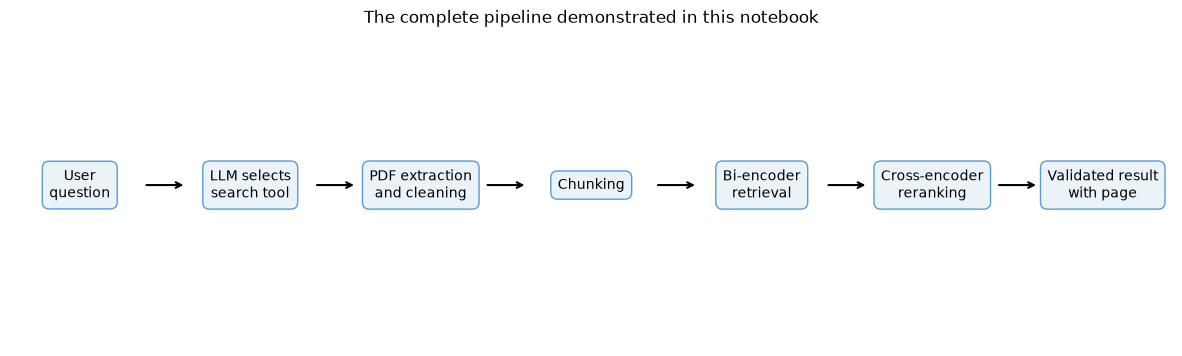

In [16]:
steps = [
    "User\nquestion",
    "LLM selects\nsearch tool",
    "PDF extraction\nand cleaning",
    "Chunking",
    "Bi-encoder\nretrieval",
    "Cross-encoder\nreranking",
    "Validated result\nwith page"
]

x_positions = np.linspace(
    0.06,
    0.94,
    len(steps)
)

plt.figure(figsize=(15, 3.8))
plt.axis("off")

for index, (x_position, step) in enumerate(
    zip(x_positions, steps)
):
    plt.text(
        x_position,
        0.55,
        step,
        ha="center",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.5",
            "facecolor": "#EAF3F8",
            "edgecolor": "#5B9BD5"
        }
    )

    if index < len(steps) - 1:
        plt.annotate(
            "",
            xy=(x_positions[index + 1] - 0.055, 0.55),
            xytext=(x_position + 0.055, 0.55),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.5
            }
        )

plt.title(
    "The complete pipeline demonstrated in this notebook",
    pad=22
)
plt.show()

<div dir="rtl" style="text-align:right">

# סיכום

השלימו בעל-פה את המשפטים:

1. LLM מייצר טקסט באמצעות __________.
2. OCR נדרש כאשר __________.
3. Overlap נועד לשמור __________.
4. Embedding הוא __________.
5. Bi-Encoder מתאים ל-__________.
6. Cross-Encoder מתאים ל-__________.
7. Function Calling אינו מריץ את הקוד בתוך המודל; הוא __________.
8. Structured Output מאפשר __________.

</div>